In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



In [31]:
train =pd.read_csv('titanic_train.csv')

In [32]:
train


,Unnamed: 0,row.names,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex
0,998,999,3rd,1,"McCarthy, Miss Katie",NaN,NaN,NaN,NaN,NaN,NaN,female
1,179,180,1st,0,"Millet, Mr Francis Davis",65.0,Southampton,"East Bridgewater, MA",NaN,NaN,(249),male
2,556,557,2nd,0,"Sjostedt, Mr Ernst Adolf",59.0,Southampton,"Sault St Marie, ON",NaN,NaN,NaN,male
3,174,175,1st,0,"McCaffry, Mr Thomas Francis",46.0,Cherbourg,"Vancouver, BC",NaN,NaN,(292),male
4,1232,1233,3rd,0,"Strilic, Mr Ivan",NaN,NaN,NaN,NaN,NaN,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...
914,455,456,2nd,1,"Ilett, Miss Bertha",17.0,Southampton,Guernsey,NaN,NaN,NaN,female
915,634,635,3rd,0,"Andreasson, Mr Paul Edvin",20.0,Southampton,"Sweden Chicago, IL",NaN,NaN,NaN,male
916,1266,1267,3rd,0,"Van Billiard, Mr Austin Blyler",NaN,NaN,NaN,NaN,NaN,NaN,male
917,1246,1247,3rd,0,"Thomas, Mr Charles",NaN,NaN,NaN,NaN,NaN,NaN,male


In [33]:
train.isnull()

,Unnamed: 0,row.names,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex
0,False,False,False,False,False,True,True,True,True,True,True,False
1,False,False,False,False,False,False,False,False,True,True,False,False
2,False,False,False,False,False,False,False,False,True,True,True,False
3,False,False,False,False,False,False,False,False,True,True,False,False
4,False,False,False,False,False,True,True,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
914,False,False,False,False,False,False,False,False,True,True,True,False
915,False,False,False,False,False,False,False,False,True,True,True,False
916,False,False,False,False,False,True,True,True,True,True,True,False
917,False,False,False,False,False,True,True,True,True,True,True,False


<Axes: >

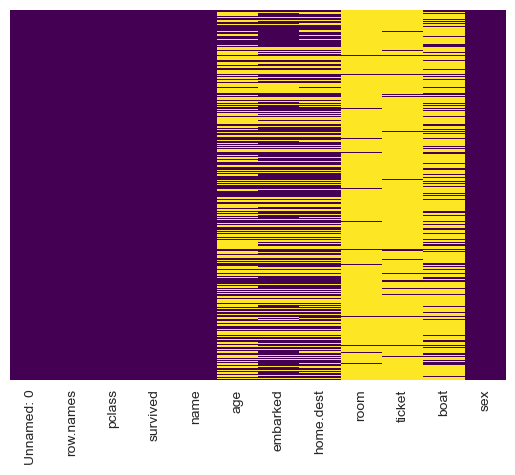

In [34]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='survived', ylabel='count'>

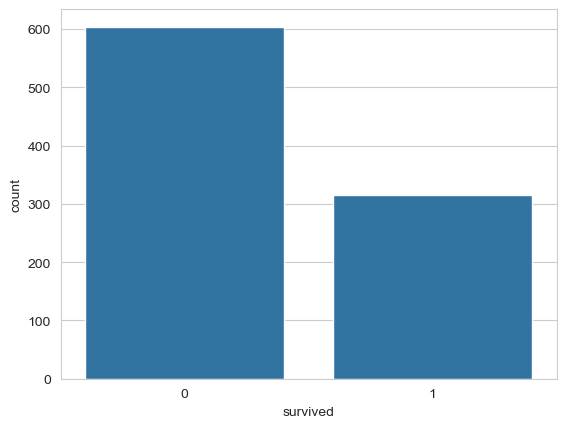

In [36]:
sns.set_style('whitegrid')
sns.countplot(x="survived",data=train)

<Axes: xlabel='survived', ylabel='count'>

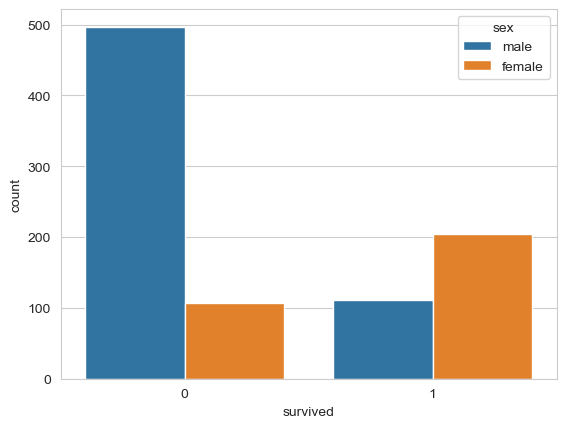

In [37]:
sns.set_style('whitegrid')
sns.countplot(x="survived", hue='sex', data=train)

<Axes: xlabel='survived', ylabel='count'>

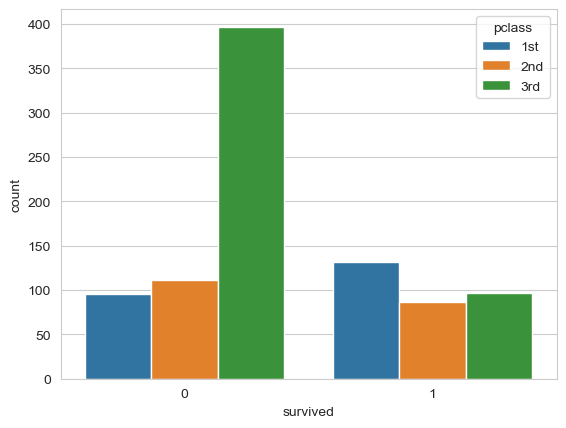

In [38]:
sns.set_style('whitegrid')
sns.countplot(x="survived", hue='pclass', data=train)

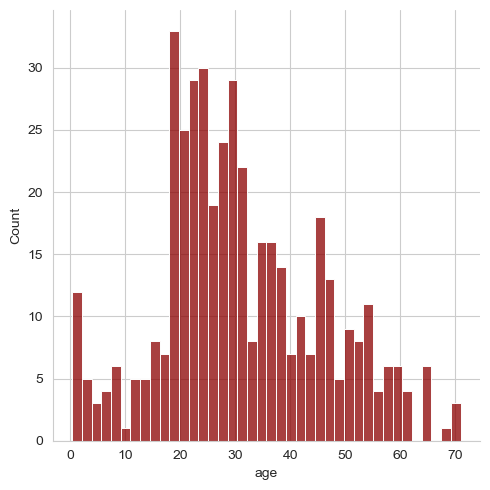

In [39]:
sns.displot(train['age'].dropna(),kde=False,color='darkred',bins=40)

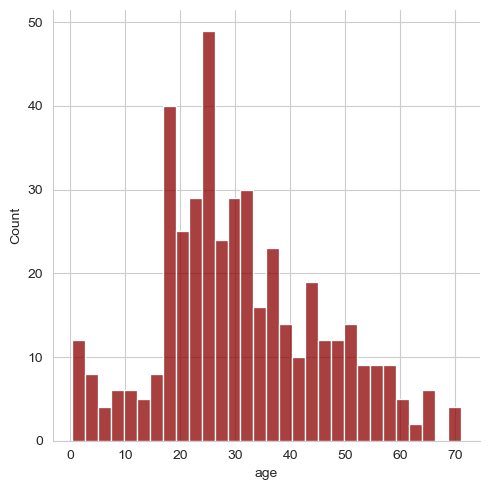

In [40]:
sns.displot(train['age'].dropna(),kde=False,color='darkred',bins=30)

In [41]:
sns.countplot(x='sibsp', data=train)

ValueError: Could not interpret value `sibsp` for `x`. An entry with this name does not appear in `data`.

In [21]:
train["Fare"].hist(color='green',bins=40,figsize=(8,4))

KeyError: 'Fare'

In [ ]:
# Cleaning

C:\Users\maha4\AppData\Local\Temp\ipykernel_12708\1230234604.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='pclass', y='age',data=train, palette='winter')


<Axes: xlabel='pclass', ylabel='age'>

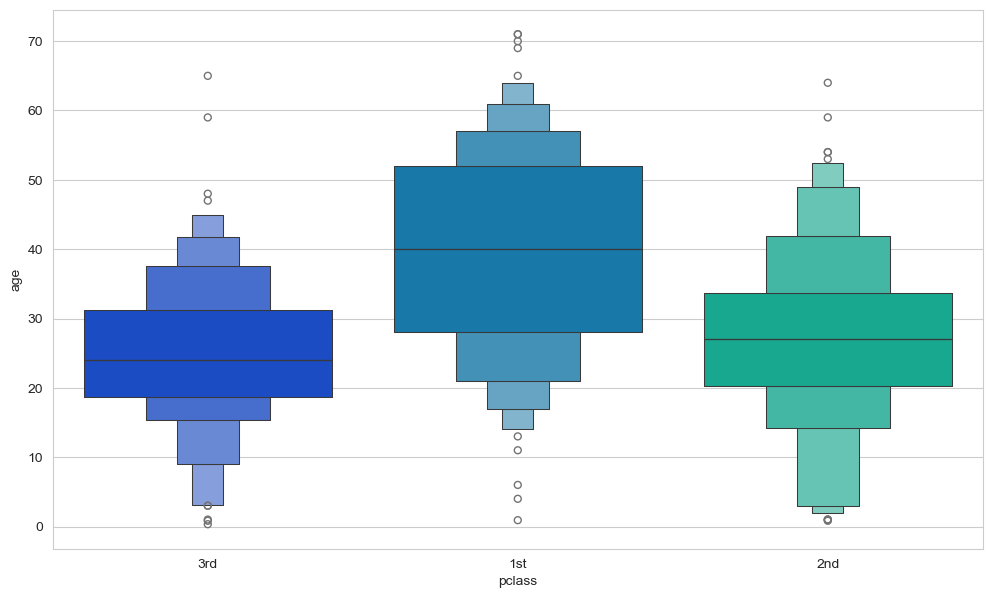

In [15]:
plt.figure(figsize=(12,7))
sns.boxenplot(x='pclass', y='age',data=train, palette='winter')

We can see weathier passengers in the classes tend to be older, which makes sense. we'll use these average age values to input based on pclass Age

In [48]:
def impute_age(cols):
    age=cols[0]
    pclass = cols[1]
    if pd.isnull(age):
       if pclass == 1:
          return 37
       elif pclass ==2:
          return 29
       else:
          return 24
    else:
      return age

In [51]:
train ['age'] = train[['age','pclass']].apply(impute_age,axis=1)

C:\Users\maha4\AppData\Local\Temp\ipykernel_12708\2733405791.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age=cols[0]
C:\Users\maha4\AppData\Local\Temp\ipykernel_12708\2733405791.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pclass = cols[1]


In [67]:
sns.heatmap(train.isnull().yticklabels=False,cbar=False,cmap='viridis')

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (2590269530.py, line 1)

In [65]:
train.drop('room',axis=1,inplace=True)


KeyError: "['room'] not found in axis"

In [66]:
train.head()

,Unnamed: 0,row.names,pclass,survived,name,age,embarked,home.dest,ticket,boat,sex
0,998,999,3rd,1,"McCarthy, Miss Katie",24.0,NaN,NaN,NaN,NaN,female
1,179,180,1st,0,"Millet, Mr Francis Davis",65.0,Southampton,"East Bridgewater, MA",NaN,(249),male
2,556,557,2nd,0,"Sjostedt, Mr Ernst Adolf",59.0,Southampton,"Sault St Marie, ON",NaN,NaN,male
3,174,175,1st,0,"McCaffry, Mr Thomas Francis",46.0,Cherbourg,"Vancouver, BC",NaN,(292),male
4,1232,1233,3rd,0,"Strilic, Mr Ivan",24.0,NaN,NaN,NaN,NaN,male


In [ ]:
tarin